# 💳 **Clasificador inteligente de gastos**

<div align="center">

## Desarrollo de un modelo de Machine Learning para categorizar transacciones financieras

</div>

<br>

**Proyecto:** FinanceAI

**Equipo:** LATAM Team 80

**Hackathon:** ONE – Proyectos G9 | Alura + Oracle

**Área:** Ciencia de Datos y Machine Learning

<br>

---

## 📌 Descripción

En este notebook se desarrolla un modelo de clasificación capaz de identificar automáticamente la categoría de un gasto a partir de la descripción de una transacción financiera.

La solución busca transformar textos como:

> "Pago mensual de Netflix"

en categorías financieras como:

> **Entretenimiento y ocio**

Este componente forma parte de **FinanceAI**, una solución orientada al análisis de hábitos financieros, la identificación de patrones de consumo y la generación de recomendaciones para mejorar la salud financiera de los usuarios.

## 🎯 Objetivo principal

Construir, evaluar y documentar un modelo de Machine Learning que clasifique automáticamente las transacciones financieras en categorías de gasto relevantes.

## 🔍 Alcance del notebook

A lo largo del análisis se realizarán las siguientes actividades:

* exploración y comprensión de los datos;
* limpieza y normalización de las descripciones;
* análisis de la distribución de categorías;
* construcción de una línea base interpretable con reglas de palabras clave;
* transformación del texto en variables numéricas;
* entrenamiento de modelos de clasificación;
* evaluación y comparación de resultados;
* análisis de errores y predicciones;
* creación de una función para clasificar nuevas transacciones.

---

> **Nota:** El notebook está diseñado con un enfoque didáctico y reproducible, explicando no solo qué se hace, sino también por qué se toma cada decisión.

# 🗂️ Contenido

1. [Planteamiento del problema](#1-planteamiento-del-problema)
2. [Configuración](#2-configuración)
3. [Carga de datos](#3-carga-de-datos)
4. [Exploración de datos (EDA)](#4-exploración-de-datos-eda)
5. [Clasificador v1 — reglas con palabras clave](#5-clasificador-v1--reglas-con-palabras-clave)
6. [Modelo v2 — clasificador entrenado](#6-modelo-v2--clasificador-entrenado)
7. [Serialización — el modelo listo para la API](#7-serialización--el-modelo-listo-para-la-api)
8. [Conclusiones, limitaciones y próximos pasos](#8-conclusiones-limitaciones-y-próximos-pasos)

# 1. Planteamiento del problema

La tarea se aborda como un problema de **clasificación supervisada multiclase** sobre texto:

| Descripción de la transacción | Categoría esperada |
| ----------------------------- | ------------------ |
| Pago mensual de Netflix       | Entretenimiento y ocio |
| Compra en supermercado        | Alimentación       |
| Factura de energía            | Vivienda y servicios |
| Viaje en Uber                 | Transporte         |

* **Entrada:** la descripción de la transacción.
* **Salida:** una de las 12 categorías definidas por el equipo.
* **Evaluación:** accuracy y F1-score por categoría, con matriz de confusión, midiendo sobre transacciones que el modelo no vio durante el entrenamiento.

Se compararán dos enfoques: una **versión 1 por reglas de palabras clave** (línea base interpretable) y una **versión 2 con Machine Learning** entrenada sobre el dataset construido por el equipo.

# 2. Configuración

Fijamos una semilla para que los resultados sean reproducibles.

In [78]:
RANDOM_STATE = 42  # semilla fija: mismos resultados en cada ejecución

# 3. Carga de datos

El dataset fue construido por el equipo mediante simulación y curaduría manual, como permite el reto: 1089 transacciones etiquetadas en 12 categorías, con montos en escala USD. Incluye tres estilos de descripción a propósito: texto manual, formato de extracto bancario y marcas locales de varios países — para reflejar datos reales.

In [79]:
import pandas as pd

url_1 = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-80-FinanceAI/feature/clasificador-gastos/dataset_gastos.csv"
df = pd.read_csv(url_1, encoding="utf-8-sig", parse_dates=["fecha"])

In [80]:
df.sample(5) # Visualizar 5 registros random

,fecha,descripcion,valor,categoria
980,2026-07-04,Medicamentos fórmula mensual,24,salud
1059,2026-07-12,Laboratorio exámenes de sangre,43,salud
97,2026-04-09,Purina Pro Plan 15kg,55,mascotas
496,2026-05-18,Ara mecato,5,alimentacion
400,2026-05-08,Karaoke con amigos,15,entretenimiento


# 4. Exploración de datos (EDA)

Antes de modelar, verificamos la calidad del dataset: estructura, valores faltantes, duplicados, balance entre categorías y rango de fechas y montos.

In [81]:
print("Columnas del dataset:\n")
print(pd.DataFrame({"Columnas" :df.columns.values}))

Columnas del dataset:

      Columnas
0        fecha
1  descripcion
2        valor
3    categoria


In [82]:
print("Cantidad de registros del dataset:\n")
print(df.shape[0])

Cantidad de registros del dataset:

1089


In [83]:
print("Tipos de datos presentes en cada columna del dataset:\n")
print(df.dtypes)

Tipos de datos presentes en cada columna del dataset:

fecha          datetime64[ns]
descripcion            object
valor                   int64
categoria              object
dtype: object


In [84]:
print("Cantidad de datos nulos en cada columna del dataset:\n")
print(df.isna().sum())

Cantidad de datos nulos en cada columna del dataset:

fecha          0
descripcion    0
valor          0
categoria      0
dtype: int64


In [85]:
print("Cantidad de registros duplicados en el dataset:\n")
print(df.duplicated().sum())

Cantidad de registros duplicados en el dataset:

6


## 4.1 Distribución por categoría

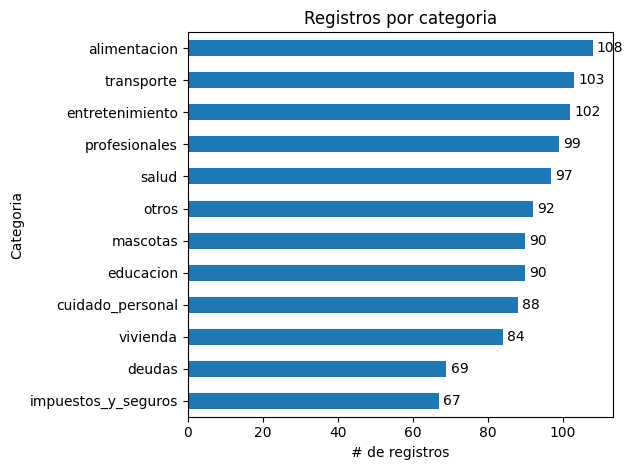

In [86]:
import matplotlib.pyplot as plt

conteo = df["categoria"].value_counts().sort_values() # Contabilizar la cantidad de registros asociados a cada categoria

ax =  conteo.plot(kind="barh", title="Registros por categoria")
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel("# de registros")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()


Las 12 categorías tienen entre 67 y 108 ejemplos. Un balance suficiente para entrenar y evaluar sin que ninguna clase domine.

## 4.2 Montos

Los montos no alimentan al clasificador (que solo lee la descripción), pero verificamos que sean coherentes.

In [87]:
print(df["valor"].describe())

count    1089.000000
mean       48.594123
std        87.418800
min         1.000000
25%        10.000000
50%        25.000000
75%        51.000000
max      1129.000000
Name: valor, dtype: float64


Dado que no hay valores negativos, no se requiere hacer limpieza adicional en el campo de valores.

# 5. Clasificador v1 — reglas con palabras clave

Nuestra línea base es un clasificador interpretable: un diccionario donde cada categoría tiene sus palabras delatoras. Dos decisiones de diseño importan aquí:

- **El orden es la prioridad:** gana la primera categoría cuya palabra aparezca. Por eso `profesionales` se evalúa primero — el propósito le gana al artículo ("Almuerzo con cliente" es gasto profesional aunque diga almuerzo).
- **Emparejamiento por palabra completa** y texto normalizado (minúsculas, sin tildes), para que "gas" no se esconda dentro de "gasolina" y "Éxito" encuentre a "exito".

In [88]:
import json
import re
import unicodedata
import requests

url_2 = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-80-FinanceAI/feature/clasificador-gastos/palabras-clave.json"

PALABRAS = requests.get(url_2).json()

def limpiar(texto):
    t = texto.lower()
    t = unicodedata.normalize("NFD", t)
    return "".join(c for c in t if unicodedata.category(c) != "Mn")

def clasificar_v1(descripcion):
    d = limpiar(descripcion)
    for categoria, palabras in PALABRAS.items():
        for p in palabras:
            if re.search(rf"\b{re.escape(p)}\b", d):
                return categoria
    return "otros"

clasificar_v1("Supermercado Éxito"), clasificar_v1("Almuerzo con cliente")

('alimentacion', 'profesionales')

## 5.1 Evaluación del clasificador v1

Evaluamos las reglas sobre las 1089 transacciones usando las mismas métricas que luego aplicaremos al modelo entrenado, para compararlos de igual a igual:

| Métrica | Qué responde |
| --- | --- |
| **Accuracy** | ¿Qué proporción del total acierta? |
| **Precision** | Cuando nombra una categoría, ¿qué tan confiable es? |
| **Recall** | De las transacciones reales de una categoría, ¿cuántas identifica? |
| **F1-score** | El equilibrio entre precision y recall. |

Resultado general: 892 de 1089 transacciones (81.9%)

                     precision    recall  f1-score   support

       alimentacion       0.92      0.54      0.68       108
   cuidado_personal       1.00      0.84      0.91        88
             deudas       0.85      0.96      0.90        69
          educacion       1.00      0.88      0.93        90
    entretenimiento       1.00      0.84      0.91       102
impuestos_y_seguros       1.00      0.87      0.93        67
           mascotas       1.00      0.74      0.85        90
              otros       0.34      0.89      0.49        92
      profesionales       0.88      0.85      0.86        99
              salud       0.95      0.77      0.85        97
         transporte       0.96      0.90      0.93       103
           vivienda       1.00      0.83      0.91        84

           accuracy                           0.82      1089
          macro avg       0.91      0.83      0.85      1089
       weighted avg       0.9

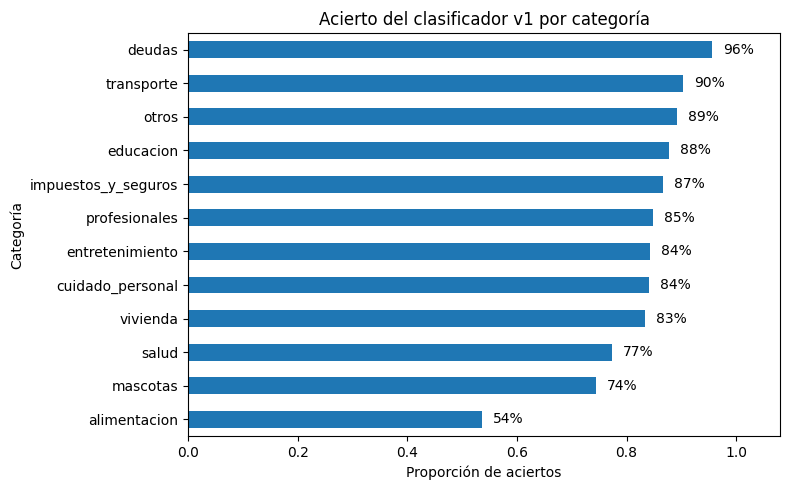

In [89]:
import sklearn
from sklearn.metrics import classification_report

df["pred_v1"] = df["descripcion"].apply(clasificar_v1)

aciertos = (df["pred_v1"] == df["categoria"]).sum()
total = len(df)
acc_v1 = aciertos / total
print(f"Resultado general: {aciertos} de {total} transacciones ({acc_v1:.1%})\n")

print(classification_report(df["categoria"], df["pred_v1"], zero_division=0))

acc_por_cat = (df["pred_v1"] == df["categoria"]).groupby(df["categoria"]).mean().sort_values()
ax = acc_por_cat.plot(kind="barh", figsize=(8, 5), xlim=(0, 1.08),
                      title="Acierto del clasificador v1 por categoría")
ax.set_xlabel("Proporción de aciertos")
ax.set_ylabel("Categoría")
for i, v in enumerate(acc_por_cat):
    ax.text(v + 0.02, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

In [90]:
errores_v1 = df.loc[df["pred_v1"] != df["categoria"], ["descripcion", "categoria", "pred_v1"]]
errores_v1 = errores_v1.rename(columns={"categoria": "real", "pred_v1": "prediccion_v1"})
print(f"Las {len(errores_v1)} transacciones que las reglas fallan:")
errores_v1

Las 197 transacciones que las reglas fallan:


,descripcion,real,prediccion_v1
2,VERCEL SUSCRIPCION PRO,profesionales,otros
5,DOG CHOW DISTRIBUIDORA,mascotas,otros
6,Tottus abarrotes,alimentacion,otros
8,Óptica lentes fórmula,salud,otros
15,Justo & Bueno,alimentacion,otros
...,...,...,...
1057,Impuesto predial cuota 2,impuestos_y_seguros,deudas
1079,GITHUB.COM MENSUAL,profesionales,otros
1084,SUPERPET CUENCA,mascotas,otros
1085,Preicfes sabatino,educacion,otros


**Conclusión de la evaluación:** las reglas aciertan el 81% (892 de 1089) y sus errores siguen un patrón claro: nombres propios que ningún diccionario genérico puede conocer ("Crepes & Waffles", "Tottus", "MOVISTAR PLAN POSPAGO") y unas pocas ambigüedades genuinas del lenguaje ("Cuota carro", "Certificación cloud examen"). Ese 18% define exactamente el trabajo del modelo de la siguiente sección: aprender de los ejemplos lo que las reglas no pueden saber.

# 6. Modelo v2 — clasificador entrenado

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

X = df["descripcion"].apply(limpiar)
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

candidatos = {
    "Regresión logística": LogisticRegression(max_iter=2000),
    "Naive Bayes": MultinomialNB(),
    "SVM lineal": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

resultados_cv, resultados_test = {}, {}

for nombre, clf in candidatos.items():
    pipe = Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2))), ("c", clf)])

    notas = cross_val_score(pipe, X_train, y_train, cv=5)
    resultados_cv[nombre] = notas

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    resultados_test[nombre] = pipe.score(X_test, y_test)

    print("=" * 25, nombre, "=" * 25)
    print(f"Validación cruzada: promedio {notas.mean():.1%} | notas: {notas.round(3)}")
    print(f"Examen (test): {pipe.score(X_test, y_test):.1%}\n")
    print(classification_report(y_test, pred, zero_division=0))

========================= Regresión logística =========================
Validación cruzada: promedio 96.0% | notas: [0.954 0.966 0.954 0.966 0.96 ]
Examen (test): 98.2%

                     precision    recall  f1-score   support

       alimentacion       1.00      1.00      1.00        22
   cuidado_personal       1.00      1.00      1.00        18
             deudas       1.00      1.00      1.00        14
          educacion       0.90      1.00      0.95        18
    entretenimiento       1.00      1.00      1.00        20
impuestos_y_seguros       1.00      1.00      1.00        13
           mascotas       1.00      1.00      1.00        18
              otros       1.00      1.00      1.00        18
      profesionales       1.00      1.00      1.00        20
              salud       1.00      0.89      0.94        19
         transporte       1.00      1.00      1.00        21
           vivienda       0.88      0.88      0.88        17

           accuracy                

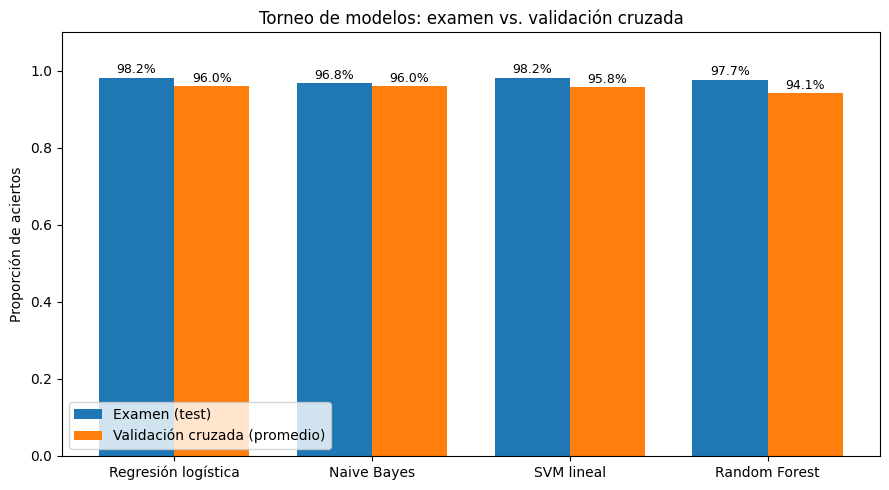

In [92]:
import numpy as np

nombres = list(resultados_test)
vals_test = [resultados_test[n] for n in nombres]
vals_cv = [resultados_cv[n].mean() for n in nombres]

x = np.arange(len(nombres))
ancho = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - ancho/2, vals_test, ancho, label="Examen (test)")
b2 = ax.bar(x + ancho/2, vals_cv, ancho, label="Validación cruzada (promedio)")
for barras in (b1, b2):
    for r in barras:
        ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.012,
                f"{r.get_height():.1%}", ha="center", fontsize=9)
ax.set_xticks(x, nombres)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Proporción de aciertos")
ax.set_title("Torneo de modelos: examen vs. validación cruzada")
ax.legend()
plt.tight_layout()
plt.show()

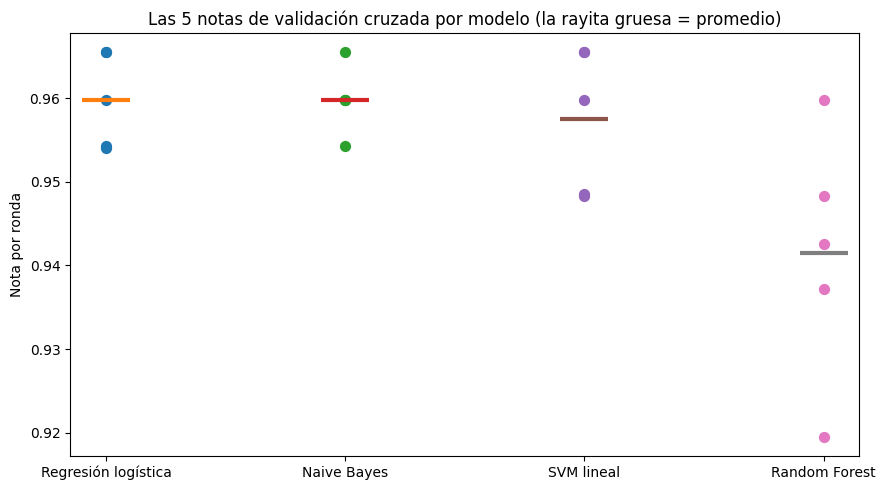

In [93]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, n in enumerate(nombres):
    notas = resultados_cv[n]
    ax.scatter([i] * len(notas), notas, s=50, zorder=3)                      # las 5 notas
    ax.scatter(i, notas.mean(), marker="_", s=1200, linewidths=3, zorder=4)  # el promedio
ax.set_xticks(range(len(nombres)), nombres)
ax.set_ylabel("Nota por ronda")
ax.set_title("Las 5 notas de validación cruzada por modelo (la rayita gruesa = promedio)")
plt.tight_layout()
plt.show()

## 6.2 Desempeño computacional

El acierto no es el único costo: el modelo elegido vivirá dentro de una API respondiendo solicitudes, su archivo serializado viajará a Object Storage y se cargará en memoria, y el equipo lo re-entrenará a medida que crezca el dataset. Medimos las tres facturas: tiempo de entrenamiento, velocidad de respuesta y peso del archivo.

In [94]:
# time: cronómetro de precisión · os: para pesar archivos · joblib: para serializar
import time
import os
import joblib

filas = []
for nombre, clf in candidatos.items():
    pipe = Pipeline([("v", TfidfVectorizer(ngram_range=(1, 2))), ("c", clf)])

    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    t_entrenar = time.perf_counter() - t0

    pipe.predict(X_test)  # calentamiento: la primera llamada siempre es más lenta
    t0 = time.perf_counter()
    for _ in range(20):
        pipe.predict(X_test)
    t_predecir = (time.perf_counter() - t0) / 20 * 1000  # promedio en milisegundos

    joblib.dump(pipe, "temp_modelo.pkl")
    peso_kb = os.path.getsize("temp_modelo.pkl") / 1024
    os.remove("temp_modelo.pkl")

    filas.append({
        "modelo": nombre,
        "entrenar (s)": round(t_entrenar, 2),
        f"clasificar {len(X_test)} transacciones (ms)": round(t_predecir, 1),
        "peso del archivo": f"{peso_kb:,.0f} KB" if peso_kb < 1024 else f"{peso_kb/1024:,.1f} MB",
    })

pd.DataFrame(filas)

,modelo,entrenar (s),clasificar 218 transacciones (ms),peso del archivo
0,Regresión logística,0.22,6.4,161 KB
1,Naive Bayes,0.01,2.3,289 KB
2,SVM lineal,0.03,2.3,161 KB
3,Random Forest,0.97,36.6,14.3 MB


## 6.3 El modelo oficial

**Decisión (criterio del equipo: mandan los resultados medidos):** el modelo oficial es el **Regresión logística**.

In [95]:
modelo = Pipeline([
    ("vectorizador", TfidfVectorizer(
        ngram_range=(1, 2),
        strip_accents="unicode",   # ← la limpieza, ahora DENTRO del modelo
    )),
    ("clasificador", LogisticRegression(max_iter=2000)),
])
modelo.fit(X_train, y_train)
print(f"Modelo oficial (regresión logística) — acierto en el examen: {modelo.score(X_test, y_test):.1%}")

Modelo oficial (regresión logística) — acierto en el examen: 98.2%


# 7. Serialización — el modelo listo para la API

Guardamos el modelo entrenado como archivo. La API lo cargará una sola vez al arrancar y lo usará para responder cada solicitud. Importante para la integración: el texto debe pasar por `limpiar()` antes de predecir.

In [96]:
# joblib: guarda y carga modelos entrenados como archivos
import joblib
import sklearn
from datetime import date

joblib.dump(modelo, "modelo_clasificador.pkl")

# La ficha técnica del modelo: con qué se entrenó, para quien lo use
with open("modelo_info.txt", "w", encoding="utf-8") as f:
    f.write("Modelo: Regresión logística — limpieza de texto incluida en el pipeline\n")
    f.write(f"Entrenado: {date.today()}\n")
    f.write(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__}\n")
    f.write(f"Datos: {len(df)} transacciones, {df['categoria'].nunique()} categorías\n")

def clasificar_gasto(descripcion):
    return modelo.predict([descripcion])[0]

for d in ["Supermercado Éxito", "PAYU*NETFLIX BOGOTA", "LAIKA MASCOTAS", "Matrícula universidad"]:
    print(f"{d!r:28} → {clasificar_gasto(d)}")

'Supermercado Éxito'         → alimentacion
'PAYU*NETFLIX BOGOTA'        → entretenimiento
'LAIKA MASCOTAS'             → mascotas
'Matrícula universidad'      → educacion


# 8. Conclusiones, limitaciones y próximos pasos

**Conclusiones.** Sí es posible clasificar transacciones a partir de su descripción. Las reglas alcanzan un 81.9% interpretable (892 de 1.089); el modelo entrenado un 98.2% sobre datos nunca vistos, aprendiendo los comercios y formatos bancarios que las reglas no conocen. El producto final es `modelo_clasificador.pkl` (12 categorías), listo para integrarse a la API.

**Limitaciones conocidas (por diseño).**

- Parte del acierto del modelo proviene de reconocer comercios *recurrentes* — el comportamiento esperado de un clasificador de transacciones; la generalización a comercios nunca vistos es menor.
- Las categorías definidas por *propósito* son el límite natural de un clasificador de texto: "Gasolina" es transporte o gasto profesional según la intención, que la descripción no siempre revela.
- El efectivo y las transferencias entre personas se asignan a `otros` deliberadamente.
- Ambigüedades léxicas conocidas: "examen" (médico vs. académico), "pensión" (educativa vs. jubilación), "vacuna" (humana vs. de mascota), "grifo" (gasolinera en Perú vs. llave de agua) y "cuota" en impuestos pagados por cuotas.
- El dataset es simulado y curado por el equipo; con datos reales, las métricas deberán recalibrarse.

**Próximos pasos.** Adaptador HTTP (`ml-service`) para la integración con el backend Java, reincorporación de la confianza si el contrato la retoma, y re-entrenamiento con las correcciones de usuarios que el backend persistirá.